# Anatomía de una Serie de Tiempo: Dataset M5 (Walmart)

> **Objetivo:** Antes de hacer forecasting, entender *por qué* una serie de tiempo se comporta como lo hace. Este notebook descompone las características fundamentales — tendencia, estacionalidad, periodicidad, autocorrelación — usando datos reales de ventas de Walmart (competencia M5 de Kaggle).

> **Audiencia:** Analytics Engineers que buscan bases sólidas en el análisis de series de tiempo.

---

## 1. Contexto y Carga de Datos

El dataset M5 contiene ventas diarias de **30,490 productos** en **10 tiendas Walmart** distribuidas en 3 estados de EE.UU. (California, Texas, Wisconsin), abarcando **~5.3 años** (ene 2011 – abr 2016).

Las tres tablas son:
- **`sales_validation`**: Unidades vendidas por producto-tienda-día (formato wide: columnas `d_1` a `d_1913`)
- **`calendar`**: Mapeo de cada `d_i` a su fecha real, día de la semana, eventos y programa SNAP
- **`sell_prices`**: Precio de venta semanal por producto-tienda

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from numpy.fft import fft, fftfreq

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110

# --- Carga ---
# Los datos ya fueron pre-agregados a nivel diario desde los parquet originales.
# Si quieres reproducir desde cero, necesitas pyarrow: pd.read_parquet('sales_validation.parquet')
agg = np.load('aggregated_sales.npz')
cal = pd.read_csv(r'C:\Users\david\Documents\M5 challenge\notebooks\serie de tiempo\calendar.csv')

cal['date'] = pd.to_datetime(cal['date'])
cal_sales = cal.iloc[:1913].copy()
cal_sales['total_sales'] = agg['daily_totals']

for cat in ['FOODS', 'HOBBIES', 'HOUSEHOLD']:
    cal_sales[f'sales_{cat}'] = agg[f'cat_{cat}']

for st in ['CA', 'TX', 'WI']:
    cal_sales[f'sales_{st}'] = agg[f'state_{st}']

print(f"Periodo: {cal_sales['date'].iloc[0].date()} → {cal_sales['date'].iloc[-1].date()}")
print(f"Días: {len(cal_sales):,}")
print(f"Ventas diarias promedio: {cal_sales['total_sales'].mean():,.0f} unidades")
print(f"Desviación estándar: {cal_sales['total_sales'].std():,.0f} unidades")

Periodo: 2011-01-29 → 2016-04-24
Días: 1,913
Ventas diarias promedio: 34,342 unidades
Desviación estándar: 7,346 unidades


## 2. La Serie en Crudo: ¿Qué vemos a simple vista?

El primer paso siempre es **mirar** la serie. Antes de cualquier modelo o transformación, la visualización nos dice si hay tendencia, patrones repetitivos, rupturas, outliers o cambios de régimen.

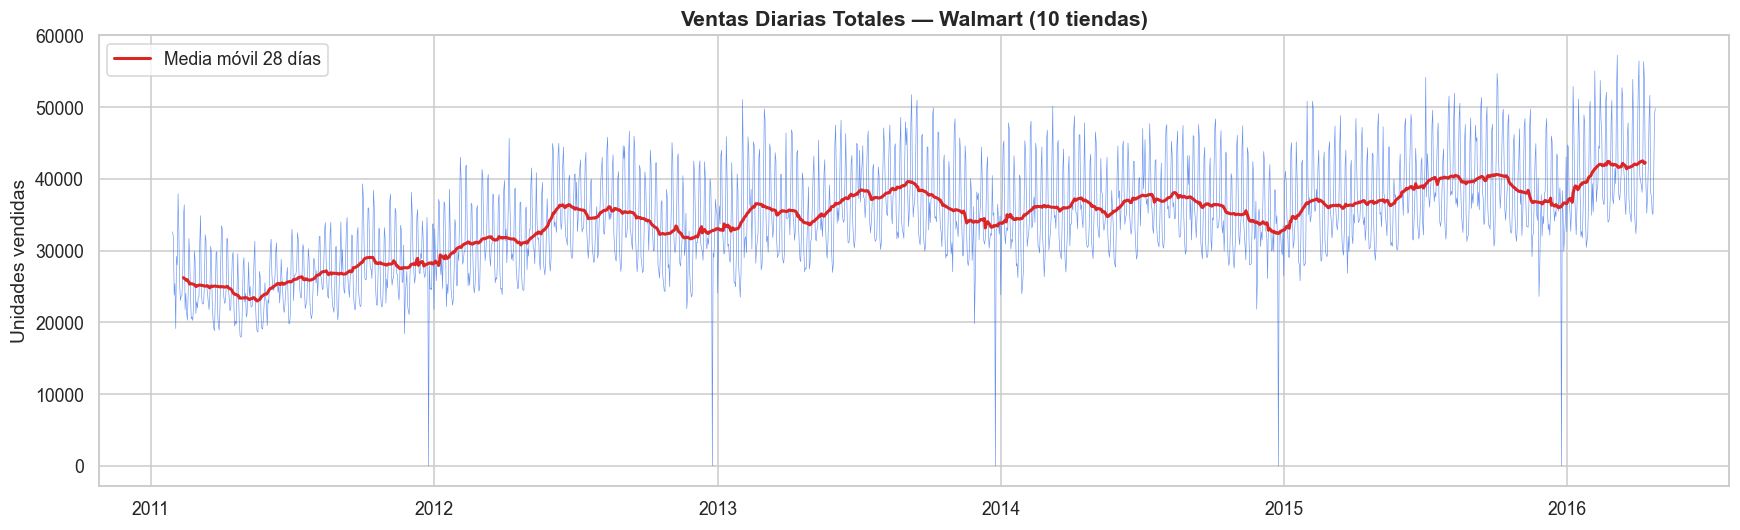

In [2]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(cal_sales['date'], cal_sales['total_sales'], linewidth=0.4, alpha=0.7, color='#2563eb')

# Media móvil de 28 días para mostrar la tendencia subyacente
ma28 = cal_sales['total_sales'].rolling(28, center=True).mean()
ax.plot(cal_sales['date'], ma28, linewidth=2, color='#dc2626', label='Media móvil 28 días')

ax.set_title('Ventas Diarias Totales — Walmart (10 tiendas)', fontsize=14, fontweight='bold')
ax.set_ylabel('Unidades vendidas')
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

**Observaciones iniciales:**
- **Tendencia positiva** moderada — las ventas crecen año con año.
- **Variabilidad semanal** evidente — el "ruido" no es aleatorio, tiene estructura.
- **Picos periódicos** que sugieren estacionalidad anual (se repiten cada ~365 días).
- **Algunos valles profundos** que podrían ser días festivos (Navidad) o eventos especiales.

La media móvil de 28 días (4 semanas exactas) suaviza la estacionalidad semanal y revela la tendencia limpia.

## 3. Estacionalidad Semanal: El Patrón Dominante

En retail, el día de la semana es el factor más fuerte de variación. Esto no es una hipótesis — los datos lo confirman.

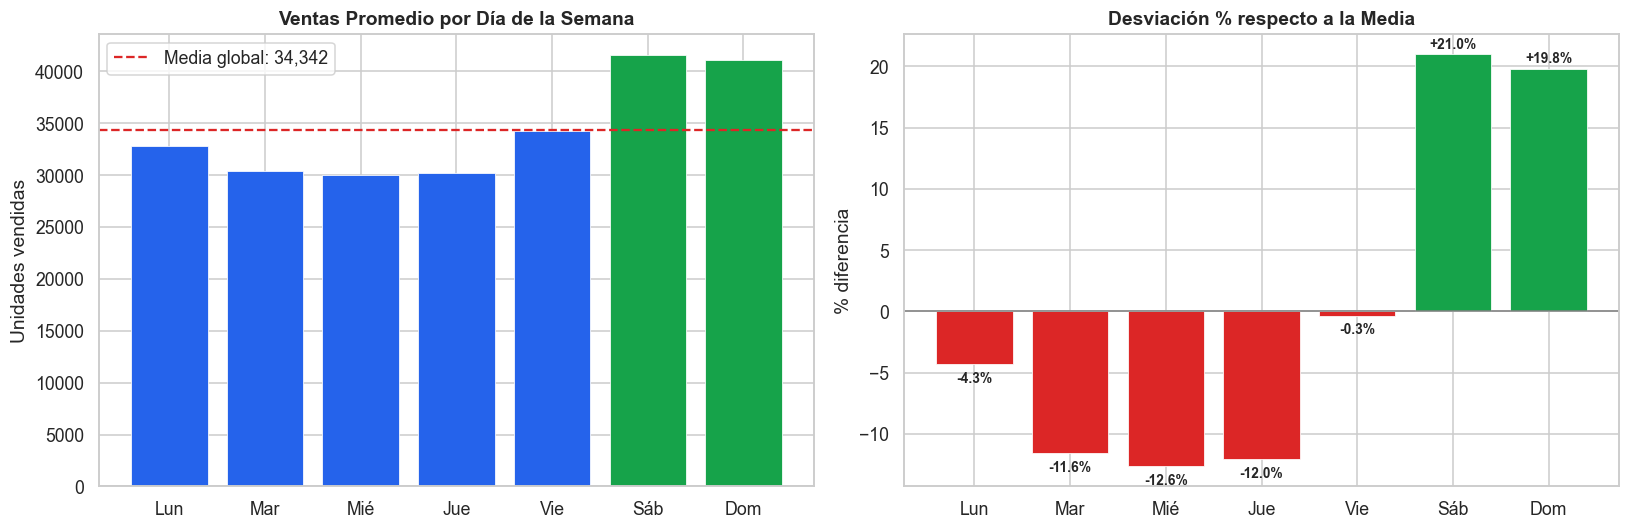

Ratio Sábado/Miércoles: 1.38x


In [3]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_labels = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

weekly_avg = cal_sales.groupby('weekday')['total_sales'].mean().reindex(day_order)
global_mean = cal_sales['total_sales'].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
colors = ['#2563eb' if v < global_mean else '#16a34a' for v in weekly_avg.values]
bars = ax1.bar(day_labels, weekly_avg.values, color=colors, edgecolor='white', linewidth=0.5)
ax1.axhline(global_mean, color='#dc2626', linestyle='--', linewidth=1.5, label=f'Media global: {global_mean:,.0f}')
ax1.set_title('Ventas Promedio por Día de la Semana', fontweight='bold')
ax1.set_ylabel('Unidades vendidas')
ax1.legend()

# Porcentaje relativo a la media
pct_diff = (weekly_avg.values / global_mean - 1) * 100
colors2 = ['#dc2626' if v < 0 else '#16a34a' for v in pct_diff]
ax2.bar(day_labels, pct_diff, color=colors2, edgecolor='white', linewidth=0.5)
ax2.axhline(0, color='gray', linewidth=1)
ax2.set_title('Desviación % respecto a la Media', fontweight='bold')
ax2.set_ylabel('% diferencia')

for i, v in enumerate(pct_diff):
    ax2.text(i, v + (0.5 if v >= 0 else -1.5), f'{v:+.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Ratio Sábado/Miércoles: {weekly_avg['Saturday']/weekly_avg['Wednesday']:.2f}x")

**¿Por qué importa?**

El fin de semana (sábado/domingo) genera ~38% más ventas que un miércoles. Esto significa que cualquier modelo de forecasting que ignore el día de la semana estará sistemáticamente equivocado. Este patrón se llama **estacionalidad semanal** y es el componente más predecible de la serie.

> **Concepto clave:** *Estacionalidad* = un patrón que se repite en intervalos fijos y conocidos. No confundir con *tendencia* (dirección general) ni con *ciclo* (fluctuación sin periodo fijo).

## 4. Periodicidad: ¿Cada cuánto se repite el patrón?

La **Transformada de Fourier (FFT)** descompone la serie en sus frecuencias constituyentes. Es como un ecualizador de audio: nos dice qué "notas" (periodos) suenan más fuerte en la señal.

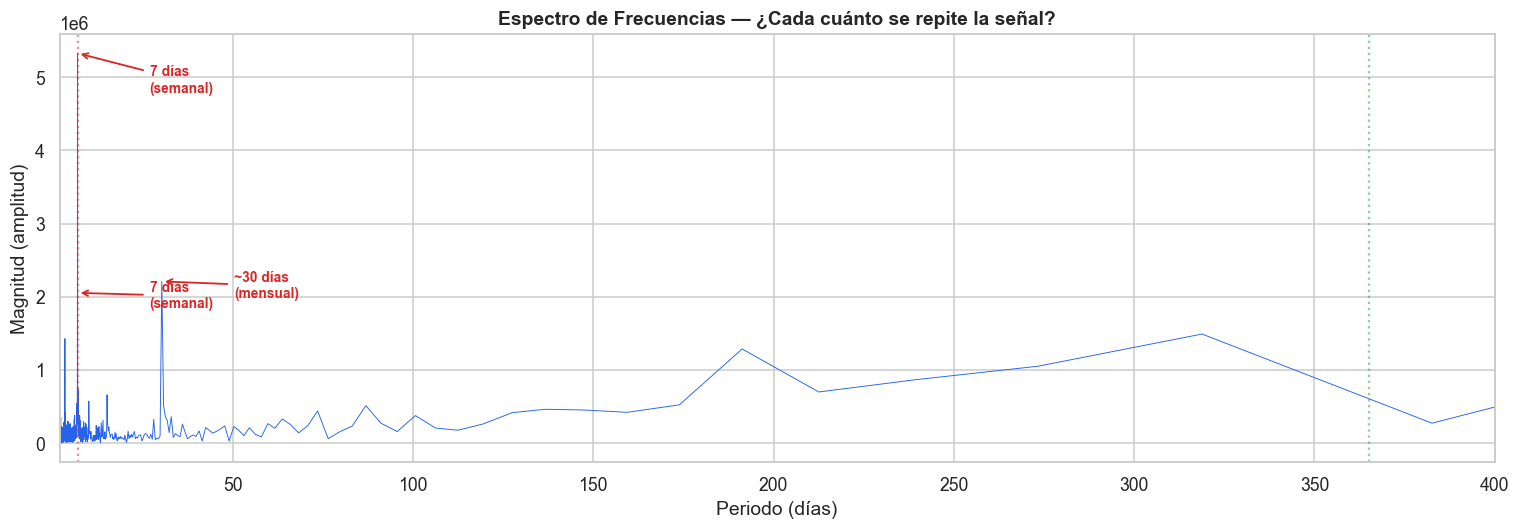

In [4]:
# FFT
y = cal_sales['total_sales'].values
N = len(y)
yf = np.abs(fft(y - y.mean()))[:N//2]
freqs = fftfreq(N, d=1)[:N//2]  # en ciclos/día
periods = 1 / freqs[1:]  # en días
magnitudes = yf[1:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(periods, magnitudes, linewidth=0.6, color='#2563eb')
ax.set_xlim(2, 400)
ax.set_xlabel('Periodo (días)')
ax.set_ylabel('Magnitud (amplitud)')
ax.set_title('Espectro de Frecuencias — ¿Cada cuánto se repite la señal?', fontweight='bold')

# Anotar los picos principales
top_idx = np.argsort(magnitudes)[-6:][::-1]
for i, idx in enumerate(top_idx):
    p = periods[idx]
    m = magnitudes[idx]
    if p < 400:
        label = ''
        if abs(p - 7) < 0.5: label = '7 días\n(semanal)'
        elif abs(p - 3.5) < 0.3: label = '3.5 días\n(armónico)'
        elif abs(p - 30.4) < 2: label = '~30 días\n(mensual)'
        elif abs(p - 365) < 20: label = '~365 días\n(anual)'
        elif abs(p - 182) < 10: label = '~182 días\n(semestral)'
        
        if label:
            ax.annotate(label, xy=(p, m), xytext=(p + 20, m * 0.9),
                       fontsize=9, fontweight='bold', color='#dc2626',
                       arrowprops=dict(arrowstyle='->', color='#dc2626', lw=1.2))

ax.axvline(7, color='#dc2626', linestyle=':', alpha=0.5)
ax.axvline(365.25, color='#16a34a', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

**Lectura del espectro:**

| Periodo | Interpretación | ¿Por qué? |
|---------|---------------|------------|
| **7 días** | Estacionalidad semanal | El pico más alto, confirma lo que vimos en §3 |
| **3.5 días** | Armónico de 7 días | Matemáticamente, un patrón de 7 días "suena" también a 3.5 |
| **~30 días** | Ciclo mensual | Probablemente ligado a quincenas, pagos y inicio de mes |
| **~182 / ~365 días** | Semestral / Anual | Estacionalidad por temporadas (verano, holidays) |

> **Concepto clave:** La FFT no asume nada sobre la forma del patrón — solo detecta repeticiones. Un pico fuerte = un periodo que explica mucha varianza. Los *armónicos* son múltiplos del periodo fundamental y no son patrones independientes.

## 5. Autocorrelación: ¿Cuánto depende el hoy del ayer?

La **autocorrelación** mide la correlación de la serie consigo misma desplazada *k* posiciones (lags). Un ACF alto en lag 7 significa: "si hoy fue un buen día, el mismo día de la semana siguiente probablemente también lo será."

Implementamos el ACF manualmente para entender qué calcula.

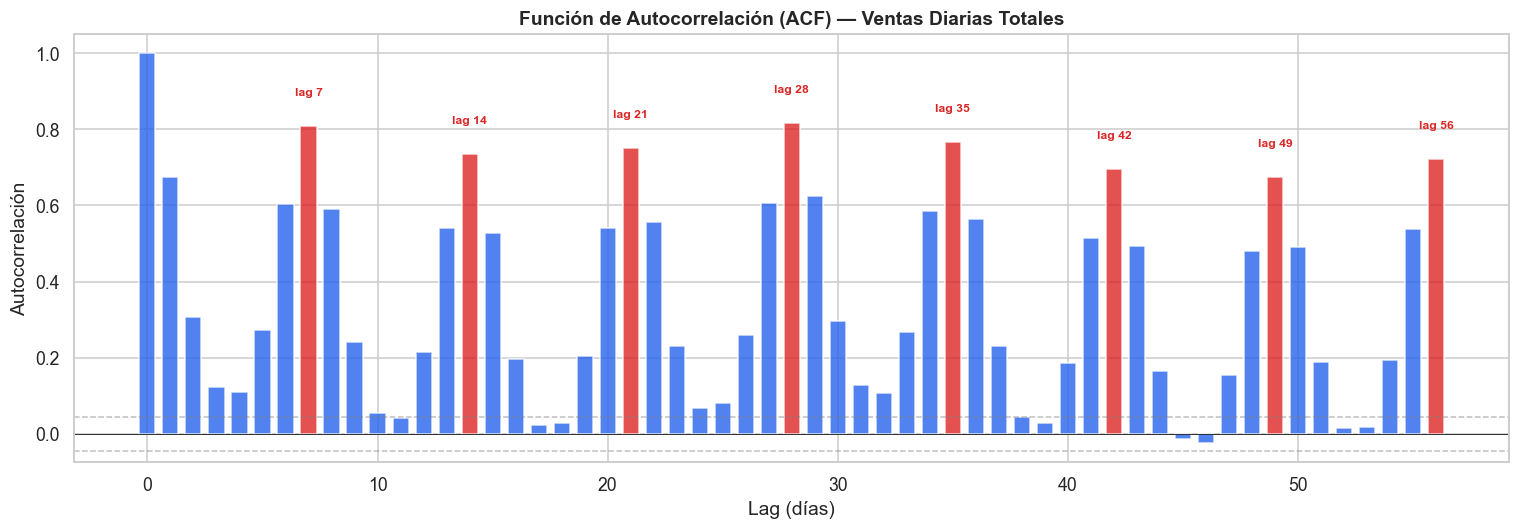

ACF en lag 1:  0.673  (ayer predice hoy)
ACF en lag 7:  0.808  (mismo día, semana pasada)
ACF en lag 14: 0.736 (mismo día, 2 semanas)
ACF en lag 28: 0.816 (mismo día, 4 semanas)


In [5]:
def manual_acf(series, max_lag=60):
    """Autocorrelación calculada desde cero (sin statsmodels)."""
    y = np.array(series, dtype=float)
    y = y - y.mean()
    n = len(y)
    variance = np.sum(y ** 2) / n
    
    acf_values = np.zeros(max_lag + 1)
    acf_values[0] = 1.0  # Lag 0 siempre es 1
    
    for lag in range(1, max_lag + 1):
        # Correlación entre y[t] y y[t-lag]
        cov = np.sum(y[lag:] * y[:-lag]) / n
        acf_values[lag] = cov / variance
    
    return acf_values

max_lag = 56  # 8 semanas
acf_vals = manual_acf(cal_sales['total_sales'], max_lag)

fig, ax = plt.subplots(figsize=(14, 5))
lags = np.arange(max_lag + 1)

# Barras con color por magnitud
colors = ['#dc2626' if lag % 7 == 0 and lag > 0 else '#2563eb' for lag in lags]
ax.bar(lags, acf_vals, color=colors, width=0.7, alpha=0.8)

# Banda de significancia (95%)
ci = 1.96 / np.sqrt(len(cal_sales))
ax.axhline(ci, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(-ci, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(0, color='black', linewidth=0.5)

ax.set_xlabel('Lag (días)')
ax.set_ylabel('Autocorrelación')
ax.set_title('Función de Autocorrelación (ACF) — Ventas Diarias Totales', fontweight='bold')

# Anotar lags semanales
for lag in [7, 14, 21, 28, 35, 42, 49, 56]:
    if lag <= max_lag:
        ax.annotate(f'lag {lag}', xy=(lag, acf_vals[lag]), 
                   xytext=(lag, acf_vals[lag] + 0.08),
                   fontsize=8, ha='center', color='#dc2626', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"ACF en lag 1:  {acf_vals[1]:.3f}  (ayer predice hoy)")
print(f"ACF en lag 7:  {acf_vals[7]:.3f}  (mismo día, semana pasada)")
print(f"ACF en lag 14: {acf_vals[14]:.3f} (mismo día, 2 semanas)")
print(f"ACF en lag 28: {acf_vals[28]:.3f} (mismo día, 4 semanas)")

**Interpretación:**

- **Lags múltiplos de 7** (rojos) tienen autocorrelación alta → el patrón semanal es fuerte y consistente.
- **Lag 1** también es significativo → hay inercia día a día (un buen lunes tiende a ser seguido de un buen martes).
- **Decaimiento gradual** de los picos semanales → la señal semanal pierde fuerza con el tiempo, pero no desaparece.

> **Concepto clave:** La ACF es fundamental para elegir modelos de forecasting. Picos en múltiplos de 7 → necesitas un modelo con componente estacional semanal (ej: SARIMA con s=7, o features de día de semana en ML).

## 6. Descomposición por Categoría y Estado

Las series agregadas esconden diferencias importantes. Veamos si FOODS, HOBBIES y HOUSEHOLD se comportan igual.

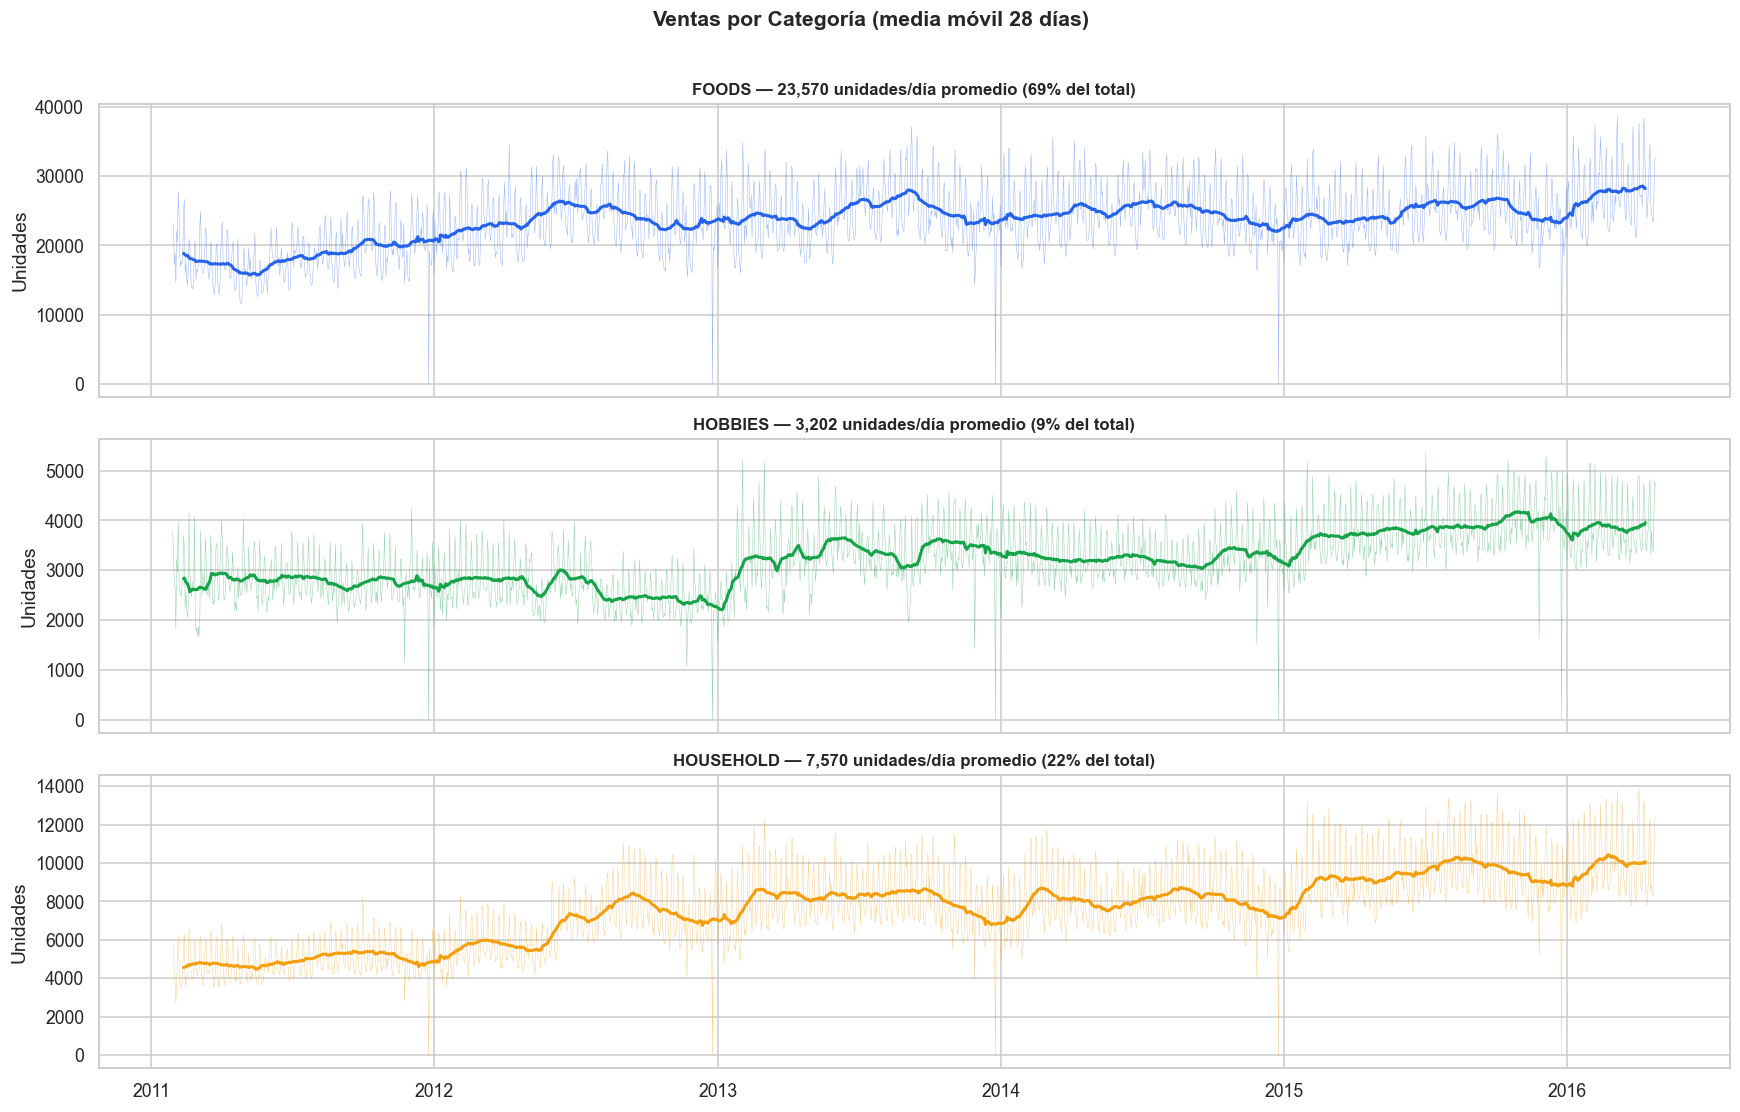

FOODS        → CV = 20.8%  (a mayor CV, más difícil de predecir)
HOBBIES      → CV = 22.1%  (a mayor CV, más difícil de predecir)
HOUSEHOLD    → CV = 29.0%  (a mayor CV, más difícil de predecir)


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

categories = {'FOODS': '#2563eb', 'HOBBIES': '#16a34a', 'HOUSEHOLD': '#f59e0b'}
for (cat, color), ax in zip(categories.items(), axes):
    y = cal_sales[f'sales_{cat}']
    ax.plot(cal_sales['date'], y, linewidth=0.3, alpha=0.5, color=color)
    ax.plot(cal_sales['date'], y.rolling(28, center=True).mean(), linewidth=2, color=color)
    ax.set_ylabel('Unidades')
    ax.set_title(f'{cat} — {y.mean():,.0f} unidades/día promedio ({y.mean()/cal_sales["total_sales"].mean()*100:.0f}% del total)', 
                fontweight='bold', fontsize=11)

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.suptitle('Ventas por Categoría (media móvil 28 días)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Coeficiente de variación por categoría
for cat in categories:
    y = cal_sales[f'sales_{cat}']
    cv = y.std() / y.mean() * 100
    print(f"{cat:12s} → CV = {cv:.1f}%  (a mayor CV, más difícil de predecir)")

**Hallazgos:**
- **FOODS** domina con ~69% del volumen y tiene la menor variabilidad relativa — es la categoría más estable y predecible.
- **HOUSEHOLD** muestra más variabilidad (CV más alto) → probablemente tiene demanda más errática o promociones más agresivas.
- **HOBBIES** es la más pequeña y también variable — series pequeñas son inherentemente más ruidosas.

> **Concepto clave:** El *coeficiente de variación* (CV = σ/μ) normaliza la variabilidad por la escala, permitiendo comparar series con niveles muy distintos.

## 7. Efecto de Eventos y SNAP

El dataset incluye eventos (festivos, deportivos, culturales) y el programa SNAP (asistencia nutricional). ¿Afectan las ventas?

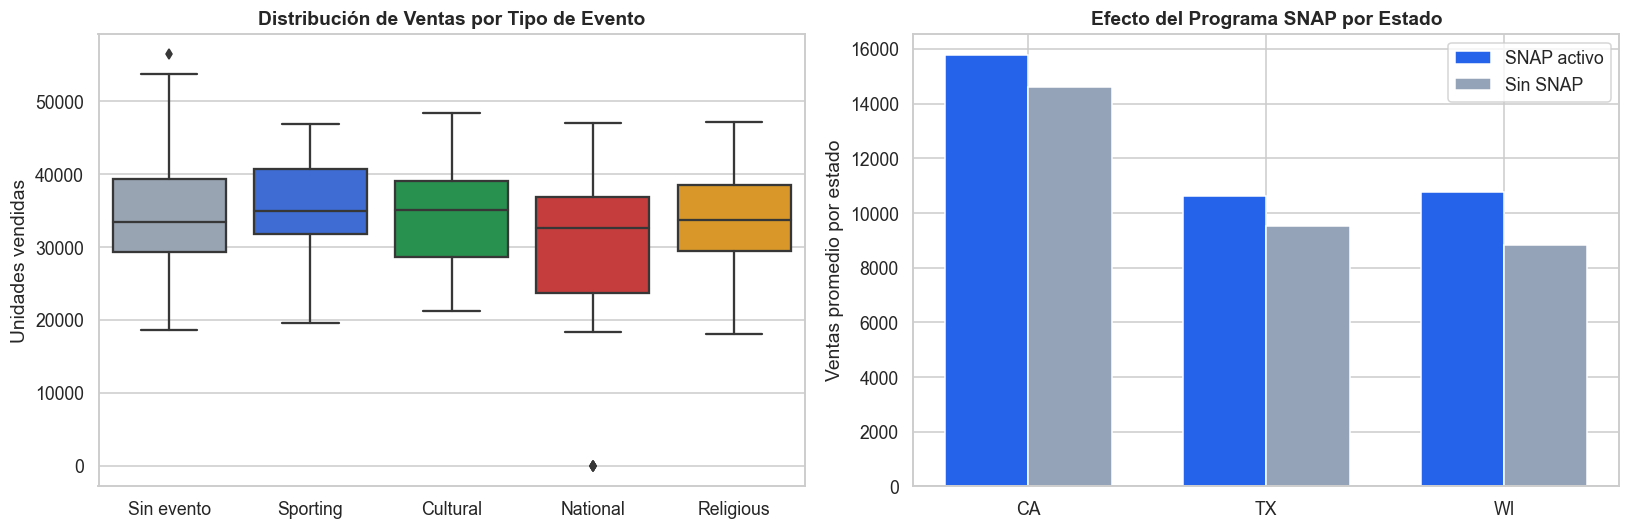

Diferencia promedio en ventas totales:
  Con evento:  32,655
  Sin evento:  34,489
  Diferencia:  -1,834


In [7]:
# Preparar datos de eventos
event_mask = cal_sales['event_name_1'].notna() & (cal_sales['event_name_1'] != 'No event')
cal_sales['has_event'] = event_mask

# Efecto por tipo de evento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot por tipo de evento
event_types_data = []
for _, row in cal_sales[event_mask].iterrows():
    event_types_data.append({'type': row['event_type_1'], 'sales': row['total_sales']})

# Agregar no-evento
for _, row in cal_sales[~event_mask].sample(500, random_state=42).iterrows():
    event_types_data.append({'type': 'Sin evento', 'sales': row['total_sales']})

df_events = pd.DataFrame(event_types_data)
order = ['Sin evento', 'Sporting', 'Cultural', 'National', 'Religious']
order = [o for o in order if o in df_events['type'].unique()]

sns.boxplot(data=df_events, x='type', y='sales', order=order, ax=ax1, 
            palette=['#94a3b8', '#2563eb', '#16a34a', '#dc2626', '#f59e0b'])
ax1.set_title('Distribución de Ventas por Tipo de Evento', fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Unidades vendidas')

# SNAP effect
snap_data = []
for state in ['CA', 'TX', 'WI']:
    snap_col = f'snap_{state}'
    sales_col = f'sales_{state}'
    mean_snap = cal_sales.loc[cal_sales[snap_col] == 1, sales_col].mean()
    mean_no = cal_sales.loc[cal_sales[snap_col] == 0, sales_col].mean()
    snap_data.append({'Estado': state, 'SNAP activo': mean_snap, 'Sin SNAP': mean_no})

df_snap = pd.DataFrame(snap_data)
x = np.arange(len(df_snap))
w = 0.35
ax2.bar(x - w/2, df_snap['SNAP activo'], w, label='SNAP activo', color='#2563eb')
ax2.bar(x + w/2, df_snap['Sin SNAP'], w, label='Sin SNAP', color='#94a3b8')
ax2.set_xticks(x)
ax2.set_xticklabels(df_snap['Estado'])
ax2.set_ylabel('Ventas promedio por estado')
ax2.set_title('Efecto del Programa SNAP por Estado', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

# Efecto numérico
print("Diferencia promedio en ventas totales:")
print(f"  Con evento:  {cal_sales.loc[event_mask, 'total_sales'].mean():,.0f}")
print(f"  Sin evento:  {cal_sales.loc[~event_mask, 'total_sales'].mean():,.0f}")
print(f"  Diferencia:  {cal_sales.loc[event_mask, 'total_sales'].mean() - cal_sales.loc[~event_mask, 'total_sales'].mean():,.0f}")

**Hallazgo contra-intuitivo:** Los días con eventos muestran ventas **más bajas** que los días normales. ¿Por qué?

Varias hipótesis:
1. Muchos eventos son días festivos donde las tiendas cierran temprano o la gente no va de compras.
2. Eventos como el Super Bowl mantienen a la gente en casa.
3. El efecto podría invertirse si miramos categorías específicas (ej: snacks suben en Super Bowl).

**SNAP** muestra un efecto positivo en CA y TX — cuando el programa está activo, las ventas suben. Esto tiene sentido económico: SNAP inyecta poder adquisitivo.

> **Concepto clave:** Las *variables exógenas* (eventos, SNAP) añaden información que la serie por sí sola no tiene. En forecasting, incluirlas como features puede mejorar significativamente la predicción.

## 8. Resumen: Componentes de la Serie

Toda serie de tiempo se puede descomponer conceptualmente en:

```
Y(t) = Tendencia + Estacionalidad + Residuo
```

| Componente | ¿Qué encontramos? | Implicación para Forecasting |
|-----------|-------------------|------------------------------|
| **Tendencia** | Crecimiento moderado año con año | Necesita un componente de tendencia (drift, trend) |
| **Estacionalidad semanal** | Pico dominante en 7 días. Sáb/Dom +38% | Feature más importante: día de la semana |
| **Estacionalidad anual** | Señal en ~365 días | Capturar con mes del año o Fourier features |
| **Efecto de eventos** | Negativo en agregado, varía por tipo | Variables exógenas caso por caso |
| **Autocorrelación** | Fuerte en lag 7, decae gradualmente | Modelos tipo AR o lag features |

### ¿Por qué no hacemos forecasting aquí?

Porque forecasting es un problema de **ingeniería**, no solo de estadística. Requiere definir:
- Horizonte de predicción (¿1 día? ¿28 días?)
- Granularidad (¿total? ¿por producto-tienda?)
- Métrica de evaluación (RMSE, WRMSSE, MAE)
- Estrategia de validación (rolling window, train/test split temporal)
- Pipeline de re-entrenamiento

Cada una de estas decisiones es un proyecto en sí mismo. Lo que hicimos aquí — entender la anatomía de la serie — es el prerequisito que informa todas esas decisiones.